# **Feed Forward Network con PyTorch**
* Oscar Ivanovich Avila Chiu 35676

En esta actividad crearás, entrenarás y evaluarás una red neuronal de arquitectura feed forward (o MLP) utilizando PyTorch y el conjunto de datos MNIST.

In [73]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import gzip
from pathlib import Path
import seaborn as sns
import math
import kagglehub
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## MNIST dataset

This is a classic dataset in machine learning, consisting of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is a 28x28 pixel grayscale image, which can be flattened into a 784-dimensional vector for input into our neural network. The goal is to classify each image into one of the 10 digit classes. The following code will load them into memory.

In [74]:
def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]

    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

    return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [89]:
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('data')

In [95]:
class MNIST_Digits(Dataset):
    def __init__(self, X, y):
      self.X = torch.tensor(X.reshape(-1, 28*28), dtype=torch.float32).to(device)
      self.y = torch.tensor(y.squeeze(), dtype=torch.long).to(device)

    def __len__(self):
      return len(self.y)

    def __getitem__(self, idx):
      return self.X[idx], self.y[idx]

In [96]:
train_data = MNIST_Digits(x_train, y_train)
val_data = MNIST_Digits(x_val, y_val)
test_data = MNIST_Digits(x_test, y_test)

print(f"Train data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Test data size: {len(test_data)}")

Train data size: 50000
Validation data size: 10000
Test data size: 10000


We can also use matplotlib to visualize the images in the dataset. Each image is a 28x28 pixel grayscale image, which can be displayed using the `imshow` function from matplotlib.

Every time you run this cell, a random number from the training set will be displayed. You can run it multiple times to see different images from the dataset.

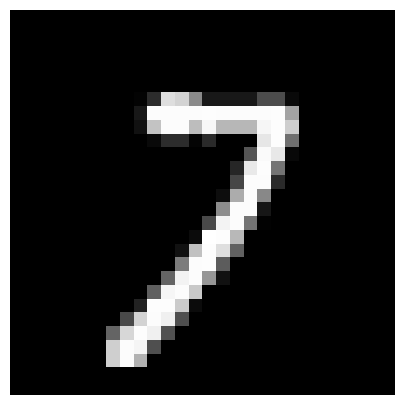

'Label: 7'

In [97]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

## Defining the Neural Network

In [98]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, patience):
  training_losses = []
  validation_losses = []

  # CAMBIO: Agregar Early Stopping
  best_val_loss = float('inf')
  epochs_no_improve = 0
  best_model_state = None

  for epoch in range(_num_epochs):
      _model.train()
      running_loss = 0.0
      for X_batch, y_batch in tqdm(_train_loader, desc=f"Epoch {epoch + 1}/{_num_epochs}"):
          _optimizer.zero_grad()
          outputs = _model(X_batch)
          loss = _criterion(outputs, y_batch)
          loss.backward()
          _optimizer.step()
          running_loss += loss.item() * X_batch.size(0)

      epoch_train_loss = running_loss / len(_train_loader.dataset)
      training_losses.append(epoch_train_loss)

      _model.eval()
      val_loss = 0.0
      with torch.no_grad():
          for X_val, y_val in _val_loader:
              val_outputs = _model(X_val)
              val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)

      epoch_val_loss = val_loss / len(_val_loader.dataset)
      validation_losses.append(epoch_val_loss)
      print(f"epoch {epoch+1} loss: {epoch_train_loss:.2f} (train) | {epoch_val_loss:.2f} (val)")
      print("")

      # CAMBIO: Agregar Early Stopping
      if epoch_val_loss < best_val_loss:
          best_val_loss = epoch_val_loss
          epochs_no_improve = 0
          best_model_state = _model.state_dict().copy()
      else:
          epochs_no_improve += 1
          # Despues de cuantas epocas esperamos a que mejore
          if epochs_no_improve >= patience:
              print(f"Early stopping triggered at epoch: {epoch+1}")
              _model.load_state_dict(best_model_state)
              break

  return training_losses, validation_losses

In [99]:
# CAMBIO: Agregar Dropout
model = nn.Sequential(
  nn.Linear(28*28, 512),
  nn.ReLU(),
  nn.Dropout(0.3),
  nn.Linear(512, 256),
  nn.ReLU(),
  nn.Dropout(0.2),
  nn.Linear(256, 10)
).to(device)

criterion = nn.CrossEntropyLoss()

#  CAMBIO: L2 regularization
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

#  CAMBIO: Aumentar Epocas y Agregar Patience para Early Stopping
num_epochs = 100
patience = 5
batch_size = 256

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size)
test_loader  = DataLoader(test_data, batch_size=batch_size)

train_losses, val_losses = train(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    patience)

Epoch 1/100: 100%|██████████| 196/196 [00:04<00:00, 43.56it/s]


epoch 1 loss: 0.82 (train) | 0.15 (val)



Epoch 2/100: 100%|██████████| 196/196 [00:05<00:00, 36.10it/s]


epoch 2 loss: 0.22 (train) | 0.12 (val)



Epoch 3/100: 100%|██████████| 196/196 [00:04<00:00, 39.46it/s]


...

epoch 12 loss: 0.09 (train) | 0.11 (val)



Epoch 13/100: 100%|██████████| 196/196 [00:06<00:00, 31.11it/s]


epoch 13 loss: 0.08 (train) | 0.09 (val)



Epoch 14/100: 100%|██████████| 196/196 [00:06<00:00, 28.85it/s]


epoch 14 loss: 0.08 (train) | 0.09 (val)

Early stopping triggered at epoch: 14


Test Accuracy: 0.9750


## Training the Neural Network

We also need to define our loss function. For multi-class classification, a common choice is the softmax cross-entropy loss. This loss function combines the softmax activation function with the cross-entropy loss, which measures the difference between the predicted probabilities and the true labels. The following function will compute the softmax cross-entropy loss and also calculate the gradients needed for backpropagation.

In [20]:
def softmaxXEntropy(x, y):
    batch_size = x.shape[1]
    exp_scores = np.exp(x)
    probs = exp_scores / exp_scores.sum(axis = 0)

    # Cost
    y_hat = probs[y.squeeze(), np.arange(batch_size)]
    cost = np.sum(-np.log(y_hat)) / batch_size

    # Gradients
    # For a softmax layer, the gradient is just the predicted probabilities minus the one-hot encoded true labels.
    probs[y.squeeze(), np.arange(batch_size)] -= 1
    x.grad = probs.copy()

    return cost


Let's also create the accuracy function to measure the performance of our model on the validation set during training.

In [21]:
def accuracy(x, y):
    pred = model.forward(x.T.view(Tensor))
    correct = np.sum(np.argmax(pred, axis=0) == y.squeeze())
    total = pred.shape[1]
    return correct/total

Let's now define the training loop for our neural network. In each epoch, we will iterate over the mini-batches of the training data, perform a forward pass to compute the predictions, calculate the loss and gradients using the softmax cross-entropy function, perform a backward pass to compute the gradients for each layer, and then update the weights using gradient descent. After each epoch, we will also evaluate the accuracy on the validation set.

In [22]:
def train(model, epochs, batch_size=128, learning_rate=1e-3):
    for epoch in range(epochs):
        epoch_iterator = tqdm(
            enumerate(create_minibatches(batch_size, x_train, y_train)),
            total=len(x_train) // batch_size,
            desc=f"Epoch {epoch+1}/{epochs}",
            leave=True
        )

        for i, (x, y) in epoch_iterator:
            scores = model.forward(x.T.view(Tensor))
            cost = softmaxXEntropy(scores, y)
            model.backward()
            model.update(learning_rate)

            epoch_iterator.set_postfix(cost=f"{cost:.4f}")

        val_acc = accuracy(x_val, y_val)
        print(f"Cost: {cost:.4f}, Val Accuracy: {val_acc:.4f}")


Let's now define our neural network architecture. It has three layers:
- Input layer with 784 neurons (one for each pixel in the input image)
- Hidden layer with 200 neurons and ReLU activation
- Output layer with 10 neurons (one for each class) and no activation function (since we will apply the softmax function in the loss function)

In [23]:
model = NeuralNetwork([
    LinearLayer(784, 200),
    ReLU(),
    LinearLayer(200, 10)])

Set up our training parameters and start training the model.

In [24]:
print(f"accuracy before training: {accuracy(x_val, y_val)}")

accuracy before training: 0.0689


In [25]:
mb_size = 256
learning_rate = 0.0001
epochs = 20
train(model, epochs, mb_size, learning_rate)

Epoch 1/20: 196it [00:03, 57.71it/s, cost=0.4381]                         


Cost: 0.4381, Val Accuracy: 0.9150


Epoch 2/20: 196it [00:03, 61.09it/s, cost=0.3465]


Cost: 0.3465, Val Accuracy: 0.9288


Epoch 3/20: 196it [00:04, 40.80it/s, cost=0.2929]                         


...

Cost: 0.0777, Val Accuracy: 0.9695


Epoch 19/20: 196it [00:03, 60.03it/s, cost=0.0739]                         


Cost: 0.0739, Val Accuracy: 0.9696


Epoch 20/20: 196it [00:03, 60.75it/s, cost=0.0704]                         


Cost: 0.0704, Val Accuracy: 0.9702


## Testing the model

With the model trained, we can now evaluate its performance on the test set. We will use the same accuracy function that we defined earlier to measure the accuracy of the model on the test set.

In [26]:
print(f'Test accuracy: {accuracy(x_test, y_test)}')

Test accuracy: 0.9672


We can also visualize the confusion matrix.

Text(0.5, 1.0, 'Confusion Matrix')

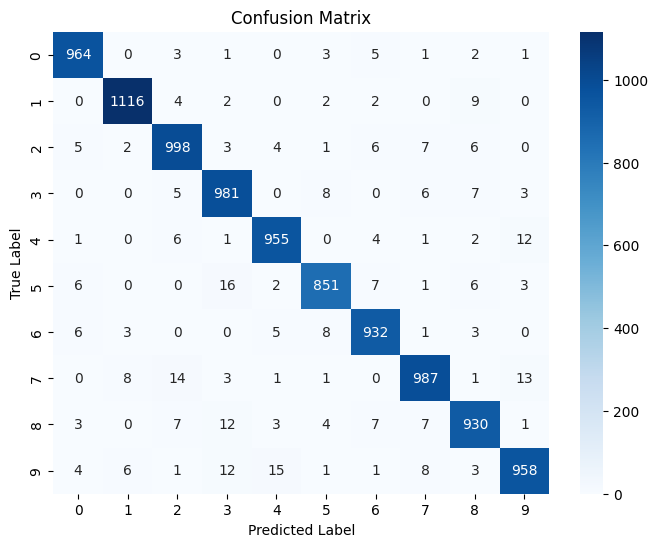

In [27]:
test_scores = model.forward(x_test.T.view(Tensor))
y_pred = np.argmax(test_scores, axis=0)
conf_matrix = np.zeros((10, 10), dtype=int)

for true_label, pred_label in zip(y_test.squeeze(), y_pred.squeeze()):
    conf_matrix[true_label, pred_label] += 1

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(10)], yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

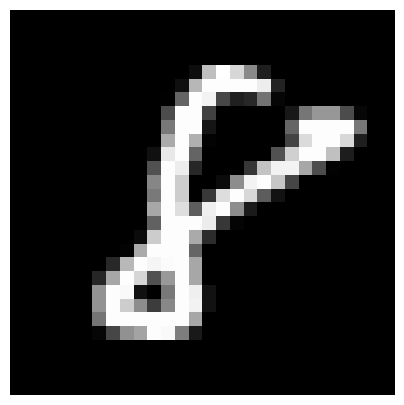

'Label: 8'

'Predicted: 8'

In [28]:
random_idx = np.random.randint(0, x_test.shape[0])
plot_number(x_test[random_idx])
display(f"Label: {y_test[random_idx].squeeze()}", f"Predicted: {y_pred[random_idx]}")